# 02 Bond Analytics

This notebook applies the Treasury benchmark curve to a small corporate bond universe and computes the main analytics used later for peer comparison and evaluated pricing.

At this stage, each bond is translated from a quoted clean price into a richer analytic record: dirty price, yield, spread to Treasury, duration, and convexity. That creates the foundation for the comp-based fair value step.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

from src.bond_math import evaluate_bond
from src.curve import build_zero_curve, make_discount_function

In [3]:
bond_path = PROJECT_ROOT / "data" / "raw" / "bond_universe.csv"
curve_path = PROJECT_ROOT / "data" / "raw" / "treasury_curve.csv"
bonds = pd.read_csv(bond_path, parse_dates=["evaluation_date", "maturity_date"])
bonds

,bond_id,issuer,ticker,evaluation_date,maturity_date,coupon_rate,clean_price,rating,sector,seniority,currency,coupon_frequency,face_value
0,AMZN_2031_425,Amazon.com Inc,AMZN,2026-04-06,2031-03-13,0.04250,99.36,A,Consumer Cyclical,Senior Unsecured,USD,2,100
1,AMZN_2036_488,Amazon.com Inc,AMZN,2026-04-06,2036-03-13,0.04875,99.31,A,Consumer Cyclical,Senior Unsecured,USD,2,100
2,META_2030_420,Meta Platforms Inc,META,2026-04-06,2030-11-15,0.04200,99.17,AA,Communications,Senior Unsecured,USD,2,100
3,META_2035_488,Meta Platforms Inc,META,2026-04-06,2035-11-15,0.04875,98.46,AA,Communications,Senior Unsecured,USD,2,100
4,PFE_2033_475,Pfizer Investment Enterprises Pte,PFE,2026-04-06,2033-05-19,0.04750,99.71,A,Consumer Non-Cyclical,Senior Unsecured,USD,2,100
5,PFE_2053_530,Pfizer Investment Enterprises Pte,PFE,2026-04-06,2053-05-19,0.05300,93.75,A,Consumer Non-Cyclical,Senior Unsecured,USD,2,100
6,F_2030_400,Ford Motor Credit Company LLC,F,2026-04-06,2030-11-13,0.04000,93.49,BBB,Consumer Cyclical,Senior Unsecured,USD,2,100
7,F_2033_713,Ford Motor Credit Company LLC,F,2026-04-06,2033-11-07,0.07125,105.39,BBB,Consumer Cyclical,Senior Unsecured,USD,2,100


In [4]:
eval_date = bonds.iloc[0]["evaluation_date"]
_, zero_curve = build_zero_curve(curve_path, eval_date=eval_date)
discount_fn, _ = make_discount_function(zero_curve)
analytics = pd.DataFrame([evaluate_bond(row, discount_fn) for _, row in bonds.iterrows()])
analytics

,bond_id,issuer,evaluation_date,maturity_date,coupon_rate,clean_price,accrued_interest,dirty_price,ytm,spread_to_curve,modified_duration,convexity,model_dirty_price
0,AMZN_2031_425,Amazon.com Inc,2026-04-06,2031-03-13,0.04250,99.36,0.277174,99.637174,0.043957,0.004108,4.392761,22.624964,99.637174
1,AMZN_2036_488,Amazon.com Inc,2026-04-06,2036-03-13,0.04875,99.31,0.317935,99.627935,0.049626,0.006153,7.767161,73.096407,99.627935
2,META_2030_420,Meta Platforms Inc,2026-04-06,2030-11-15,0.04200,99.17,1.647514,100.817514,0.043974,0.004290,4.079847,19.814878,100.817514
3,META_2035_488,Meta Platforms Inc,2026-04-06,2035-11-15,0.04875,98.46,1.912293,100.372293,0.050777,0.007494,7.433917,67.899733,100.372293
4,PFE_2033_475,Pfizer Investment Enterprises Pte,2026-04-06,2033-05-19,0.04750,99.71,1.810773,101.520773,0.047977,0.006182,5.872394,41.422157,101.520773
5,PFE_2053_530,Pfizer Investment Enterprises Pte,2026-04-06,2053-05-19,0.05300,93.75,2.020442,95.770442,0.057573,0.010392,13.584471,279.318540,95.770442
6,F_2030_400,Ford Motor Credit Company LLC,2026-04-06,2030-11-13,0.04000,93.49,1.591160,95.081160,0.056206,0.016347,4.052990,19.557217,95.081160
7,F_2033_713,Ford Motor Credit Company LLC,2026-04-06,2033-11-07,0.07125,105.39,2.952348,108.342348,0.062186,0.020095,5.699646,41.132394,108.342348


In [5]:
analytics_display = analytics[["bond_id", "dirty_price", "ytm", "spread_to_curve", "modified_duration", "convexity"]].copy()
for col in ["ytm", "spread_to_curve"]:
    analytics_display[col] = analytics_display[col] * 100
analytics_display

,bond_id,dirty_price,ytm,spread_to_curve,modified_duration,convexity
0,AMZN_2031_425,99.637174,4.395722,0.410798,4.392761,22.624964
1,AMZN_2036_488,99.627935,4.962635,0.615303,7.767161,73.096407
2,META_2030_420,100.817514,4.397376,0.429018,4.079847,19.814878
3,META_2035_488,100.372293,5.077693,0.749408,7.433917,67.899733
4,PFE_2033_475,101.520773,4.797688,0.618221,5.872394,41.422157
5,PFE_2053_530,95.770442,5.757310,1.039226,13.584471,279.318540
6,F_2030_400,95.081160,5.620559,1.634674,4.052990,19.557217
7,F_2033_713,108.342348,6.218607,2.009549,5.699646,41.132394


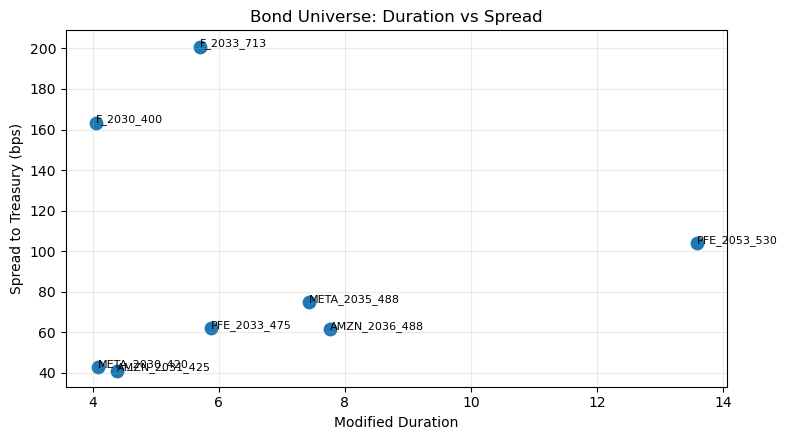

In [6]:
plt.figure(figsize=(8, 4.5))
plt.scatter(analytics["modified_duration"], analytics["spread_to_curve"] * 10000, s=80)
for row in analytics.itertuples(index=False):
    plt.annotate(row.bond_id, (row.modified_duration, row.spread_to_curve * 10000), fontsize=8)
plt.xlabel("Modified Duration")
plt.ylabel("Spread to Treasury (bps)")
plt.title("Bond Universe: Duration vs Spread")
plt.grid(alpha=0.25)
plt.tight_layout()

These results make it easier to line the bonds up on spread and rate risk. Even in this small sample, they give a quick sense of which names are likely to make reasonable comps.